# RQ1 - Which LLM configurations are most suitable for deploying the Multiple AI-Agents layer?

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

ROOT = Path("/Users/ivan/Desktop/AP4Fed/Experiments_100r_docker")
BASELINES = ["never", "random", "expert-driven"]
AGENTIC = ["voting-based", "role-based", "debate-based"]
DISPLAY_ORDER = ["never", "random", "expert-driven", "voting-based", "role-based", "debate-based"]
DISPLAY_NAMES = {
    "never": "Never",
    "random": "Random",
    "expert-driven": "Expert-Driven",
    "voting-based": "Voting-based",
    "role-based": "Role-based",
    "debate-based": "Debate-based",
}

if not ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {ROOT}")
print(f"Using results from: {ROOT}")


def canonical_name(name):
    raw = str(name).strip().lower().replace("_", "-")
    aliases = {
        "expert driven": "expert-driven",
        "voting based": "voting-based",
        "role based": "role-based",
        "debate based": "debate-based",
    }
    return aliases.get(raw, raw)


def pick_col(df, candidates):
    def norm(s):
        return re.sub(r"\s+", " ", str(s).strip().lower())

    cols = [(norm(c), c) for c in df.columns]
    for pat in candidates:
        p = pat.lower()
        for lc, orig in cols:
            if p in lc:
                return orig
    return None


def choose_f1_col(df):
    cols = list(df.columns)
    cand = [c for c in cols if "f1" in c.lower()]
    prio = [c for c in cand if any(k in c.lower() for k in ["val", "valid", "test"])]
    if prio:
        return prio[0]
    if cand:
        return cand[0]
    acc = [c for c in cols if "accuracy" in c.lower()]
    acc_prio = [c for c in acc if any(k in c.lower() for k in ["val", "valid", "test"])]
    if acc_prio:
        return acc_prio[0]
    return acc[0] if acc else None


def to_num_series(series):
    cleaned = (
        series.astype(str)
        .str.replace("\u202f", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    cleaned = cleaned.str.replace(r"(sec\.?|s)$", "", regex=True)
    return pd.to_numeric(cleaned, errors="coerce")


def last_valid_value(series):
    values = to_num_series(series).dropna()
    return float(values.iloc[-1]) if len(values) else np.nan


def summarize_run(path):
    df = pd.read_csv(path)
    round_col = pick_col(df, ["FL Round", "Round"])
    if round_col is None:
        raise ValueError(f"Missing round column in {path}")

    f1_col = choose_f1_col(df)
    total_col = pick_col(df, ["Total Time of FL Round", "Total Round Time", "Total Time"])
    training_col = pick_col(df, ["Training Time"])
    comm_col = pick_col(df, ["Communication Time"])
    agent_col = pick_col(df, ["Agent Time (s)", "Agent Time", "Reasoning Overhead", "Agent Overhead"])

    temp = df.copy()
    temp[round_col] = pd.to_numeric(temp[round_col], errors="coerce")
    temp = temp.dropna(subset=[round_col]).sort_values(round_col)

    rows = []
    for round_id, sub in temp.groupby(round_col, sort=True):
        rows.append(
            {
                "round": int(round_id),
                "f1": last_valid_value(sub[f1_col]) if f1_col else np.nan,
                "training_time": float(to_num_series(sub[training_col]).mean()) if training_col else np.nan,
                "communication_time": float(to_num_series(sub[comm_col]).mean()) if comm_col else np.nan,
                "total_time": last_valid_value(sub[total_col]) if total_col else np.nan,
                "agent_time": last_valid_value(sub[agent_col]) if agent_col else np.nan,
            }
        )

    rounds = pd.DataFrame(rows).sort_values("round")
    f1_values = pd.to_numeric(rounds["f1"], errors="coerce").dropna()
    total_values = pd.to_numeric(rounds["total_time"], errors="coerce").dropna()
    train_values = pd.to_numeric(rounds["training_time"], errors="coerce").dropna()
    comm_values = pd.to_numeric(rounds["communication_time"], errors="coerce").dropna()
    agent_values = pd.to_numeric(rounds["agent_time"], errors="coerce").dropna()
    positive_agent_values = agent_values[agent_values > 0]

    final_val_f1 = float(f1_values.iloc[-1]) if len(f1_values) else np.nan
    best_val_f1 = float(f1_values.max()) if len(f1_values) else np.nan
    mean_total_round_time = float(total_values.mean()) if len(total_values) else np.nan

    return {
        "configuration": canonical_name(path.parent.name),
        "run": path.stem,
        "source_path": str(path),
        "final_val_f1": final_val_f1,
        "best_val_f1": best_val_f1,
        "mean_training_time": float(train_values.mean()) if len(train_values) else np.nan,
        "mean_communication_time": float(comm_values.mean()) if len(comm_values) else np.nan,
        "mean_total_round_time": mean_total_round_time,
        "total_fl_time": float(total_values.sum()) if len(total_values) else np.nan,
        "mean_agent_time": float(positive_agent_values.mean()) if len(positive_agent_values) else 0.0,
        "total_agent_time": float(positive_agent_values.sum()) if len(positive_agent_values) else 0.0,
        "decision_rounds": int(len(positive_agent_values)),
        "efficiency_score": (final_val_f1 / mean_total_round_time) if len(total_values) and not np.isnan(final_val_f1) else np.nan,
    }


def mean_std(values):
    arr = np.asarray([float(v) for v in values if not pd.isna(v)], dtype=float)
    if arr.size == 0:
        return np.nan, np.nan, 0
    if arr.size == 1:
        return float(arr[0]), 0.0, 1
    return float(arr.mean()), float(arr.std(ddof=1)), int(arr.size)


def vargha_delaney_a12(reference, candidate):
    ref = np.asarray([float(v) for v in reference if not pd.isna(v)], dtype=float)
    cand = np.asarray([float(v) for v in candidate if not pd.isna(v)], dtype=float)
    if ref.size == 0 or cand.size == 0:
        return np.nan
    wins = 0.0
    for value in cand:
        wins += np.sum(value > ref)
        wins += 0.5 * np.sum(value == ref)
    return float(wins / (cand.size * ref.size))


def effect_size_label(a12):
    if pd.isna(a12):
        return ""
    magnitude = max(a12, 1.0 - a12)
    if magnitude > 0.70:
        return "L"
    if magnitude > 0.63:
        return "M"
    if magnitude > 0.55:
        return "S"
    return "N"


def favours(reference_name, candidate_name, metric_goal, a12):
    if pd.isna(a12) or abs(a12 - 0.5) < 1e-12:
        return "tie"
    if metric_goal == "higher":
        return candidate_name if a12 > 0.5 else reference_name
    return candidate_name if a12 < 0.5 else reference_name


def build_pairwise_stats(run_summary, comparisons, metrics):
    rows = []
    for family, reference_name, candidate_name in comparisons:
        reference_df = run_summary[run_summary["configuration"] == reference_name]
        candidate_df = run_summary[run_summary["configuration"] == candidate_name]
        if reference_df.empty or candidate_df.empty:
            continue

        for metric_key, metric_label, metric_goal in metrics:
            reference_values = reference_df[metric_key].dropna().tolist()
            candidate_values = candidate_df[metric_key].dropna().tolist()
            if not reference_values or not candidate_values:
                continue

            test = mannwhitneyu(candidate_values, reference_values, alternative="two-sided", method="auto")
            a12 = vargha_delaney_a12(reference_values, candidate_values)
            ref_mean, ref_std, ref_n = mean_std(reference_values)
            cand_mean, cand_std, cand_n = mean_std(candidate_values)
            rows.append(
                {
                    "Comparison Family": family,
                    "Metric": metric_label,
                    "Metric Goal": metric_goal,
                    "Reference Configuration": reference_name,
                    "Candidate Configuration": candidate_name,
                    "Reference Mean": ref_mean,
                    "Reference Std": ref_std,
                    "Reference N": ref_n,
                    "Candidate Mean": cand_mean,
                    "Candidate Std": cand_std,
                    "Candidate N": cand_n,
                    "Mann-Whitney U": float(test.statistic),
                    "P Value": float(test.pvalue),
                    "Significant (p<0.05)": bool(test.pvalue < 0.05),
                    "A12 (candidate > reference)": a12,
                    "Effect Size": effect_size_label(a12),
                    "Favours": favours(reference_name, candidate_name, metric_goal, a12),
                }
            )
    return pd.DataFrame(rows)


run_rows = []
for exp_dir in sorted([d for d in ROOT.iterdir() if d.is_dir()]):
    files = sorted(
        [f for f in exp_dir.glob("r[0-9]*.csv") if re.fullmatch(r"r\d+\.csv", f.name)],
        key=lambda x: int(re.search(r"\d+", x.stem).group()),
    )
    for path in files:
        run_rows.append(summarize_run(path))

run_summary = pd.DataFrame(run_rows)
if run_summary.empty:
    raise ValueError(f"No experiment folders with rN.csv files found in {ROOT}")

run_summary = run_summary.sort_values(["configuration", "run"]).reset_index(drop=True)
run_summary["Configuration"] = run_summary["configuration"].map(lambda x: DISPLAY_NAMES.get(x, x))

summary_rows = []
for config in [c for c in DISPLAY_ORDER if c in set(run_summary["configuration"])]:
    sub = run_summary[run_summary["configuration"] == config]
    acc_mean, acc_std, acc_n = mean_std(sub["final_val_f1"])
    fl_mean, fl_std, _ = mean_std(sub["total_fl_time"])
    over_mean, over_std, _ = mean_std(sub["total_agent_time"])
    summary_rows.append(
        {
            "Configuration": DISPLAY_NAMES.get(config, config),
            "Model Accuracy (mean ± std)": f"{acc_mean:.2f} ± {acc_std:.2f}" if not np.isnan(acc_mean) else "",
            "Total FL Time (mean ± std)": f"{int(round(fl_mean))} ± {int(round(fl_std))} s" if not np.isnan(fl_mean) else "",
            "Agent Overhead (mean ± std)": f"{int(round(over_mean))} ± {int(round(over_std))} s" if not np.isnan(over_mean) else "",
            "n_runs": acc_n,
        }
    )

summary_table = pd.DataFrame(summary_rows)
display(summary_table)
summary_table.to_csv(ROOT / "LLM_summary_stats.csv", index=False)

rq2_run_summary = run_summary[run_summary["configuration"].isin(BASELINES + AGENTIC)].copy()
rq2_run_summary.to_csv(ROOT / "rq2_run_summary.csv", index=False)

rq2_metrics = [
    ("final_val_f1", "Final Validation F1", "higher"),
    ("mean_training_time", "Average Training Time", "lower"),
    ("mean_communication_time", "Average Communication Time", "lower"),
    ("mean_total_round_time", "Average Total Round Time", "lower"),
]
rq2_comparisons = [
    ("agentic_vs_baseline", baseline, agentic)
    for baseline in BASELINES
    for agentic in AGENTIC
    if baseline in set(rq2_run_summary["configuration"]) and agentic in set(rq2_run_summary["configuration"])
]
rq2_stats = build_pairwise_stats(rq2_run_summary, rq2_comparisons, rq2_metrics)
if not rq2_stats.empty:
    rq2_stats["Reference Configuration"] = rq2_stats["Reference Configuration"].map(lambda x: DISPLAY_NAMES.get(x, x))
    rq2_stats["Candidate Configuration"] = rq2_stats["Candidate Configuration"].map(lambda x: DISPLAY_NAMES.get(x, x))
print("=== RQ2 statistical analysis ===")
display(rq2_stats)
rq2_stats.to_csv(ROOT / "rq2_statistical_analysis.csv", index=False)

rq3_run_summary = run_summary[run_summary["configuration"].isin(AGENTIC)].copy()
rq3_run_summary.to_csv(ROOT / "rq3_run_summary.csv", index=False)

rq3_metrics = [
    ("mean_agent_time", "Mean Agent Overhead", "lower"),
    ("total_agent_time", "Total Agent Overhead", "lower"),
]
rq3_comparisons = [
    ("agentic_pairwise_overhead", left, right)
    for idx, left in enumerate(AGENTIC)
    for right in AGENTIC[idx + 1 :]
    if left in set(rq3_run_summary["configuration"]) and right in set(rq3_run_summary["configuration"])
]
rq3_stats = build_pairwise_stats(rq3_run_summary, rq3_comparisons, rq3_metrics)
if not rq3_stats.empty:
    rq3_stats["Reference Configuration"] = rq3_stats["Reference Configuration"].map(lambda x: DISPLAY_NAMES.get(x, x))
    rq3_stats["Candidate Configuration"] = rq3_stats["Candidate Configuration"].map(lambda x: DISPLAY_NAMES.get(x, x))
print("=== RQ3 statistical analysis ===")
display(rq3_stats)
rq3_stats.to_csv(ROOT / "rq3_statistical_analysis.csv", index=False)



# Pattern activation frequency

In [ ]:
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("/Users/ivan/Desktop/AP4Fed/Experiments_100r_docker")
if not ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {ROOT}")
print(f"Using results from: {ROOT}")

DISPLAY_NAMES = {
    "never": "Never",
    "random": "Random",
    "expert-driven": "Expert-Driven",
    "voting-based": "Voting-based",
    "role-based": "Role-based",
    "debate-based": "Debate-based",
}
FOLDER_ORDER = list(DISPLAY_NAMES.keys())
PATTERN_NAMES = ["CS", "MC", "HDH"]
COLOR_ON = "#66C28C"
COLOR_OFF = "#E06B6B"
EDGE_COLOR = "#30363d"
EDGE_LW = 0.5
ALPHA_BAR = 0.95

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["hatch.color"] = "#777777"
plt.rcParams["hatch.linewidth"] = 0.6
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

LEGEND_HANDLES = [
    mpatches.Patch(facecolor=COLOR_ON, edgecolor=EDGE_COLOR, linewidth=EDGE_LW, label="Architectural Pattern Active"),
    mpatches.Patch(facecolor=COLOR_OFF, edgecolor=EDGE_COLOR, linewidth=EDGE_LW, hatch="xx", label="Architectural Pattern Not Active"),
]


def parse_ap_list(value):
    if pd.isna(value):
        return None
    tokens = re.findall(r"\bON\b|\bOFF\b", str(value).upper())
    if not tokens:
        return None
    if len(tokens) < 6:
        tokens = tokens + ["OFF"] * (6 - len(tokens))
    return tokens[:6]


def latest_common_run(root: Path) -> int:
    available = {}
    for folder in FOLDER_ORDER:
        runs = []
        for path in (root / folder).glob("r[0-9]*.csv"):
            match = re.fullmatch(r"r(\d+)\.csv", path.name)
            if match:
                runs.append(int(match.group(1)))
        available[folder] = sorted(runs)
    if not all(available.values()):
        missing = [folder for folder, runs in available.items() if not runs]
        raise ValueError(f"Missing rN.csv files for: {', '.join(missing)}")
    return sorted(set.intersection(*[set(runs) for runs in available.values()]))[-1]


selected_run = latest_common_run(ROOT)
plot_rounds = set()
states = {}
for folder in FOLDER_ORDER:
    csv_path = ROOT / folder / f"r{selected_run}.csv"
    df = pd.read_csv(csv_path)
    round_col = next((c for c in df.columns if "fl round" in c.lower()), None)
    ap_col = next((c for c in df.columns if "ap list" in c.lower()), None)
    if round_col is None or ap_col is None:
        raise ValueError(f"Missing FL Round or AP List column in {csv_path}")

    states[DISPLAY_NAMES[folder]] = {"CS": {}, "MC": {}, "HDH": {}}
    for round_id_value, sub in df.groupby(round_col):
        try:
            round_int = int(round_id_value)
        except Exception:
            continue
        values = sub[ap_col].dropna()
        tokens = parse_ap_list(values.iloc[-1]) if len(values) else None
        plot_rounds.add(round_int)
        if tokens is None:
            cs = mc = hdh = 0
        else:
            cs = 1 if tokens[0] == "ON" else 0
            mc = 1 if tokens[2] == "ON" else 0
            hdh = 1 if tokens[5] == "ON" else 0
        states[DISPLAY_NAMES[folder]]["CS"][round_int] = cs
        states[DISPLAY_NAMES[folder]]["MC"][round_int] = mc
        states[DISPLAY_NAMES[folder]]["HDH"][round_int] = hdh

available_rounds = sorted(plot_rounds)
if not available_rounds:
    raise ValueError(f"No round values found in run r{selected_run}")

fig_height = max(4.5, len(available_rounds) * 0.4)
fig, ax = plt.subplots(figsize=(12, fig_height))
x_col_w = 0.03
x_gap = 0.00
group_gap = 0.05
rect_height = 0.6

display_order = [DISPLAY_NAMES[folder] for folder in FOLDER_ORDER]
x_lefts = {}
for group_idx, approach_name in enumerate(display_order):
    x_base = group_idx * (3 * (x_col_w + x_gap) + group_gap)
    for pattern_idx, pattern_name in enumerate(PATTERN_NAMES):
        x_lefts[(approach_name, pattern_name)] = x_base + pattern_idx * (x_col_w + x_gap)

all_lefts = [x_lefts[(approach_name, pattern_name)] for approach_name in display_order for pattern_name in PATTERN_NAMES]
ax.set_xlim(min(all_lefts) - 0.02, max(all_lefts) + x_col_w + 0.05)
ax.set_ylim(min(available_rounds) - 0.5, max(available_rounds) + 0.5)
ax.set_ylabel("Federated Learning Round")
ax.set_yticks(available_rounds)

for approach_name in display_order:
    for pattern_name in PATTERN_NAMES:
        x_left = x_lefts[(approach_name, pattern_name)]
        for round_value in available_rounds:
            state = states[approach_name][pattern_name].get(round_value, 0)
            ax.barh(
                y=round_value,
                width=x_col_w,
                left=x_left,
                height=rect_height,
                color=COLOR_ON if state else COLOR_OFF,
                edgecolor=EDGE_COLOR,
                linewidth=EDGE_LW,
                hatch=None if state else "xx",
                alpha=ALPHA_BAR,
                zorder=3,
            )

trans = ax.get_xaxis_transform()
for approach_name in display_order:
    for pattern_name in PATTERN_NAMES:
        x_center = x_lefts[(approach_name, pattern_name)] + x_col_w / 2.0
        ax.text(x_center, -0.03, pattern_name, transform=trans, ha="center", va="top", fontsize=10, clip_on=False)

for group_idx, approach_name in enumerate(display_order):
    x_base = group_idx * (3 * (x_col_w + x_gap) + group_gap)
    x_group_center = x_base + (x_col_w + x_gap) + x_col_w / 2.0
    ax.text(x_group_center, -0.10, approach_name, transform=trans, ha="center", va="top", fontsize=11, clip_on=False)

ax.grid(False)
ax.set_xticks([])
ax.tick_params(axis="x", length=0)
ax.legend(handles=LEGEND_HANDLES, loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2, frameon=True, framealpha=0.9)
plt.subplots_adjust(bottom=0.18)
plt.savefig(ROOT / "patternActivationVert.pdf", bbox_inches="tight", dpi=600, facecolor="white")
plt.show()



# RQ 2 - How effective is the Multiple AI-Agents layer in improving FL system evaluation metrics?

Using results from: /Users/ivan/Desktop/AP4Fed/Experiments_100r_docker


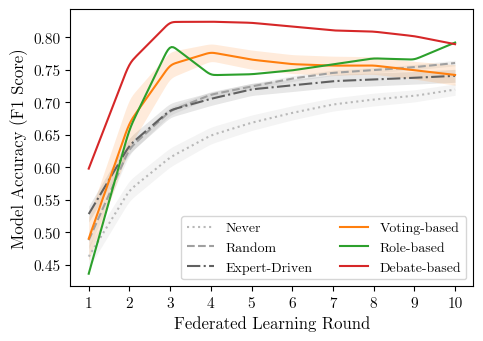

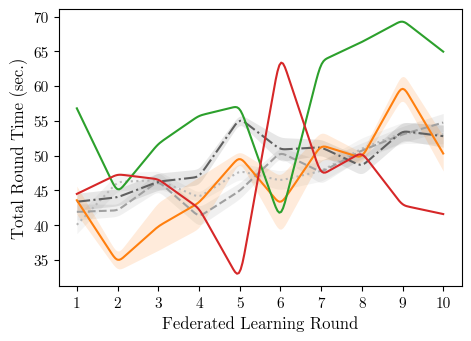

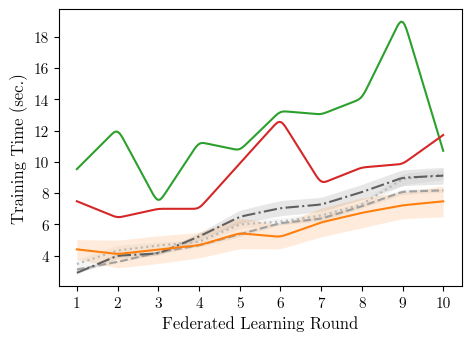

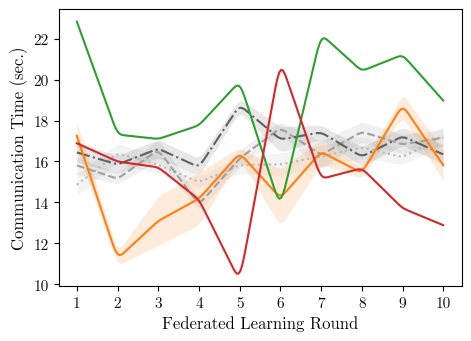

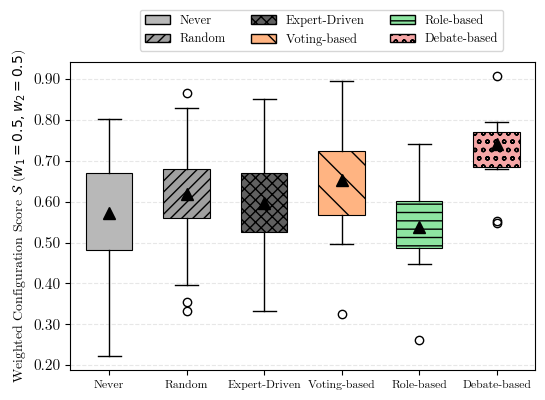

In [2]:
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

ROOT = Path("/Users/ivan/Desktop/AP4Fed/Experiments_100r_docker")
if not ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {ROOT}")
print(f"Using results from: {ROOT}")

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

folders = {
    "never": "Never",
    "expert-driven": "Expert-Driven",
    "random": "Random",
    "voting-based": "Voting-based",
    "role-based": "Role-based",
    "debate-based": "Debate-based",
}
order = ["Never", "Random", "Expert-Driven", "Voting-based", "Role-based", "Debate-based"]
COLORS = {
    "Never": "#b8b8b8",
    "Random": "#a0a0a0",
    "Expert-Driven": "#606060",
    "Voting-based": "#ff7f0e",
    "Role-based": "#2ca02c",
    "Debate-based": "#d62728",
}
LINESTYLES = {
    "Never": ":",
    "Random": "--",
    "Expert-Driven": "-.",
    "Voting-based": "-",
    "Role-based": "-",
    "Debate-based": "-",
}
AGENT_COLORS = {
    "Voting-based": "#FFB482",
    "Role-based": "#8DE5A1",
    "Debate-based": "#F6A6A6",
}
HATCHES = {
    "Never": "",
    "Random": "///",
    "Expert-Driven": "XXX",
    "Voting-based": "\\",
    "Role-based": "--",
    "Debate-based": "oo",
}
FIGSIZE = (5.2, 3.6)
BOX_FIGSIZE = (6.0, 4.0)


def load_round_metrics(root: Path) -> pd.DataFrame:
    round_metrics_path = root / "round_metrics.csv"
    if round_metrics_path.exists():
        df = pd.read_csv(round_metrics_path)
        return df[["approach", "run", "round", "F1", "total_time", "training_time", "communication_time"]].copy()

    rows = []
    for folder_name, display_name in folders.items():
        for path in sorted((root / folder_name).glob("r[0-9]*.csv")):
            if not re.fullmatch(r"r\d+\.csv", path.name):
                continue
            df = pd.read_csv(path)
            time_col = next((c for c in ["Total Round Time", "Total Time of FL Round", "Total Time"] if c in df.columns), None)
            round_col = next((c for c in df.columns if c.lower() == "fl round" or "fl round" in c.lower()), None)
            f1_col = next((c for c in df.columns if c.lower() == "val f1" or ("f1" in c.lower() and "val" in c.lower())), None)
            training_col = next((c for c in df.columns if c.lower() == "training time"), None)
            comm_col = next((c for c in df.columns if c.lower() == "communication time"), None)
            if not time_col or not round_col or not f1_col:
                continue
            temp = df.copy()
            for col in [round_col, f1_col, time_col, training_col, comm_col]:
                if col is not None:
                    temp[col] = pd.to_numeric(temp[col].astype(str).str.replace("\u202f", "", regex=False).str.replace(" ", "", regex=False).str.replace(",", ".", regex=False), errors="coerce")
            temp = temp.dropna(subset=[round_col]).sort_values(round_col)
            for round_id, sub in temp.groupby(round_col):
                row = sub.tail(1).iloc[0]
                rows.append({
                    "approach": display_name,
                    "run": path.stem,
                    "round": int(round_id),
                    "F1": row.get(f1_col, np.nan),
                    "total_time": row.get(time_col, np.nan),
                    "training_time": row.get(training_col, np.nan) if training_col else np.nan,
                    "communication_time": row.get(comm_col, np.nan) if comm_col else np.nan,
                })
    if not rows:
        raise ValueError(f"No round-level experiment rows found in {root}")
    return pd.DataFrame(rows)


G = load_round_metrics(ROOT)
for col in ["round", "F1", "total_time", "training_time", "communication_time"]:
    G[col] = pd.to_numeric(G[col], errors="coerce")
G = G.dropna(subset=["round", "F1", "total_time"]).copy()
A = G.groupby(["approach", "round"]).agg({
    "F1": ["mean", "std", "count"],
    "total_time": ["mean", "std", "count"],
    "training_time": ["mean", "std", "count"],
    "communication_time": ["mean", "std", "count"],
})

present = [approach for approach in order if approach in A.index.get_level_values("approach").unique()]
xt = sorted(int(value) for value in A.index.get_level_values("round").unique())
if not xt:
    raise ValueError("No round values available for plotting")


def pick_xticks(values, target=10):
    values = list(values)
    if len(values) <= target:
        return values
    idxs = np.linspace(0, len(values) - 1, target, dtype=int)
    return [values[idx] for idx in idxs]


def kfmt(x, pos):
    if x == 0:
        return "0"
    if abs(x) >= 1000:
        value = x / 1000.0
        return f"{value:.1f}k" if (value % 1) else f"{int(value)}k"
    return f"{int(x)}"


def light_smooth(x, y, num_points=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 4:
        return x, y
    x_new = np.linspace(x.min(), x.max(), num_points)
    y_interp = np.interp(x_new, x, y)
    window = min(11, len(y_interp) - (len(y_interp) + 1) % 2)
    if window < 5:
        return x_new, y_interp
    kernel = np.blackman(window)
    kernel /= kernel.sum()
    y_smoothed = np.convolve(y_interp, kernel, mode="same")
    y_smoothed[:window] = y_interp[:window]
    y_smoothed[-window:] = y_interp[-window:]
    return x_new, y_smoothed


def draw(metric, ylabel, yfmt=False, fname=None, show_legend=False):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.grid(False)

    for approach in present:
        stat = A.loc[approach, metric]
        x = stat.index.values.astype(float)
        y = stat["mean"].values.astype(float)
        s = stat["std"].fillna(0).values.astype(float)
        n = stat["count"].clip(lower=1).values.astype(float)
        ci = 0.5 * s / np.sqrt(n)
        lo, hi = y - ci, y + ci
        if metric == "F1":
            lo, hi = np.clip(lo, 0, 1), np.clip(hi, 0, 1)

        if len(x) > 5:
            xf, yf = light_smooth(x, y)
            _, lof = light_smooth(x, lo)
            _, hif = light_smooth(x, hi)
            ax.plot(xf, yf, linestyle=LINESTYLES[approach], label=approach, color=COLORS[approach], linewidth=1.5, zorder=3)
            ax.fill_between(xf, lof, hif, alpha=0.15, color=COLORS[approach], lw=0, zorder=2)
        else:
            ax.plot(x, y, linestyle=LINESTYLES[approach], label=approach, color=COLORS[approach], linewidth=1.5, zorder=3)
            ax.fill_between(x, lo, hi, alpha=0.15, color=COLORS[approach], lw=0, zorder=2)

    ax.set_xlabel("Federated Learning Round")
    ax.set_ylabel(ylabel)
    ax.set_xticks(pick_xticks(xt))
    if yfmt:
        ax.yaxis.set_major_formatter(FuncFormatter(kfmt))
    if show_legend:
        ax.legend(ncol=2, frameon=True, loc="best", fontsize=10)

    fig.savefig(ROOT / (fname or f"{metric}.pdf"), bbox_inches="tight", dpi=600)
    plt.show()


def draw_score_boxplot(df_source, value_col, ylabel, fname):
    fig, ax = plt.subplots(figsize=BOX_FIGSIZE)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3, zorder=0)
    ax.grid(False, axis="x")

    data, labels = [], []
    for approach in order:
        sub = df_source.loc[df_source["approach"] == approach, value_col].dropna()
        if sub.empty:
            continue
        data.append(sub.values)
        labels.append(approach)

    if not data:
        raise ValueError("No score values available for boxplot")

    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6, zorder=3)
    for patch, label in zip(bp["boxes"], labels):
        face = AGENT_COLORS.get(label, COLORS.get(label, "#cccccc"))
        patch.set(facecolor=face, edgecolor="black", linewidth=0.8, hatch=HATCHES.get(label, ""), zorder=3)

    for median in bp["medians"]:
        x, y = median.get_xdata(), median.get_ydata()
        ax.plot(np.mean(x), np.mean(y), marker="^", markersize=8, color="black", zorder=10)
        median.set_alpha(0)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="x", labelsize=8.5)

    legend_patches = [
        mpatches.Patch(facecolor=AGENT_COLORS.get(label, COLORS[label]), hatch=HATCHES.get(label, ""), label=label, edgecolor="black")
        for label in labels
    ]
    ax.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.54, 1.19), ncol=3, fontsize=9, frameon=True)

    fig.savefig(ROOT / fname, bbox_inches="tight", dpi=600)
    plt.show()


W1 = 0.5
W2 = 0.5

if not np.isclose(W1 + W2, 1.0):
    raise ValueError("W1 and W2 must sum to 1.")


def minmax_norm(series: pd.Series) -> pd.Series:
    smin = series.min()
    smax = series.max()
    if pd.isna(smin) or pd.isna(smax):
        return pd.Series(np.nan, index=series.index)
    if np.isclose(smax, smin):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - smin) / (smax - smin)


def inv_minmax_norm(series: pd.Series) -> pd.Series:
    smin = series.min()
    smax = series.max()
    if pd.isna(smin) or pd.isna(smax):
        return pd.Series(np.nan, index=series.index)
    if np.isclose(smax, smin):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (smax - series) / (smax - smin)


G_plot = G.copy()
G_plot["acc_norm"] = minmax_norm(G_plot["F1"])
G_plot["time_norm"] = inv_minmax_norm(G_plot["total_time"])
G_plot["score_sim"] = W1 * G_plot["acc_norm"] + W2 * G_plot["time_norm"]

draw("F1", "Model Accuracy (F1 Score)", False, "F1.pdf", show_legend=True)
draw("total_time", "Total Round Time (sec.)", True, "TotalTime.pdf")
draw("training_time", "Training Time (sec.)", True, "TrainingTime.pdf")
draw("communication_time", "Communication Time (sec.)", True, "CommTime.pdf")
draw_score_boxplot(
    G_plot,
    "score_sim",
    rf"Weighted Configuration Score $\mathcal{{S}}$ ($w_1={W1}, w_2={W2}$)",
    "ScoreSim_Boxplot.pdf",
)


# RQ3 - What is the computational overhead introduced by the Multiple AI-Agents layer?

Using results from: /Users/ivan/Desktop/AP4Fed/Experiments_100r_docker


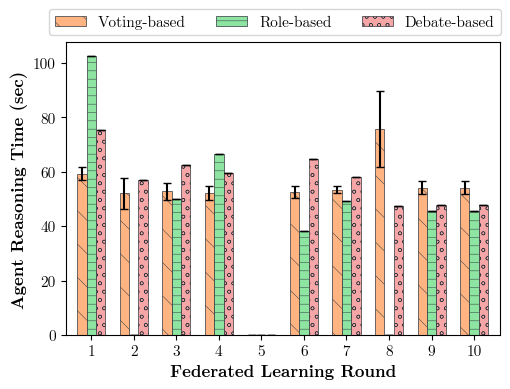

=== Agent reasoning time summary (rounds 1–10) ===
Voting-based: per-round mean = 50.64 s, total over plotted rounds = 506.36 s
Role-based: per-round mean = 39.74 s, total over plotted rounds = 397.36 s
Debate-based: per-round mean = 52.05 s, total over plotted rounds = 520.47 s


In [2]:
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("/Users/ivan/Desktop/AP4Fed/Experiments_100r_docker")
if not ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {ROOT}")
print(f"Using results from: {ROOT}")

plt.rcParams.update({
    "font.family": "CMU Serif",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.labelweight": "bold",
    "hatch.color": "#777777",
    "hatch.linewidth": 0.35,
})

FIGSIZE = (5.6, 3.8)
EDGE_COLOR = "#30363d"
EDGE_LW = 0.5
ORDER = ["Voting-based", "Role-based", "Debate-based"]
FOLDER_MAP = {"Voting-based": "voting-based", "Role-based": "role-based", "Debate-based": "debate-based"}
COLORS = {"Voting-based": "#FFB482", "Role-based": "#8DE5A1", "Debate-based": "#F6A6A6"}
HATCHES = {"Voting-based": "\\", "Role-based": "--", "Debate-based": "oo"}


def load_agent_rows(root: Path) -> pd.DataFrame:
    round_metrics_path = root / "round_metrics.csv"
    if round_metrics_path.exists():
        df = pd.read_csv(round_metrics_path)
        df = df[df["approach"].isin(ORDER)].copy()
        return df[["approach", "run", "round", "agent_time"]]

    rows = []
    for approach, folder in FOLDER_MAP.items():
        for path in sorted((root / folder).glob("r[0-9]*.csv")):
            if not re.fullmatch(r"r\d+\.csv", path.name):
                continue
            df = pd.read_csv(path)
            round_col = next((c for c in df.columns if "fl round" in c.lower()), None)
            agent_col = next((c for c in df.columns if "agent" in c.lower() and "time" in c.lower()), None)
            if round_col is None or agent_col is None:
                continue
            temp = df.copy()
            temp[round_col] = pd.to_numeric(temp[round_col], errors="coerce")
            temp[agent_col] = pd.to_numeric(temp[agent_col].astype(str).str.replace("\u202f", "", regex=False).str.replace(" ", "", regex=False).str.replace(",", ".", regex=False), errors="coerce")
            temp = temp.dropna(subset=[round_col])
            for round_id, sub in temp.groupby(round_col):
                values = sub[agent_col].dropna()
                agent_time = float(values.iloc[-1]) if len(values) else np.nan
                rows.append({"approach": approach, "run": path.stem, "round": int(round_id), "agent_time": agent_time})
    if not rows:
        raise ValueError(f"No agent-time rows found in {root}")
    return pd.DataFrame(rows)


round_df = load_agent_rows(ROOT)
for col in ["round", "agent_time"]:
    round_df[col] = pd.to_numeric(round_df[col], errors="coerce")
round_df = round_df.dropna(subset=["round", "agent_time"]).copy()
if round_df.empty:
    raise ValueError("No agent-time rows available for Voting/Role/Debate")

rounds = sorted(int(value) for value in round_df["round"].unique())
labels = np.array(rounds)
stats = round_df.groupby(["approach", "round"])["agent_time"].agg(["mean", "std", "count"]).reset_index()
means, errs = {}, {}
for approach in ORDER:
    sub = stats[stats["approach"] == approach].set_index("round").reindex(rounds)
    mean = sub["mean"].fillna(0.0).to_numpy(dtype=float)
    if sub["count"].fillna(0).max() > 1:
        std = sub["std"].fillna(0.0).to_numpy(dtype=float)
        count = sub["count"].fillna(1.0).to_numpy(dtype=float)
        err = std / np.sqrt(count)
    else:
        err = np.zeros_like(mean)
    means[approach] = mean
    errs[approach] = err * 0.7

fig, ax = plt.subplots(figsize=FIGSIZE)
width = 0.22
offsets = np.linspace(-width, width, len(ORDER))
for idx, approach in enumerate(ORDER):
    x = labels + offsets[idx]
    ax.bar(
        x,
        means[approach],
        width=width,
        yerr=errs[approach],
        capsize=3,
        color=COLORS[approach],
        hatch=HATCHES[approach],
        alpha=1.0,
        edgecolor=EDGE_COLOR,
        linewidth=EDGE_LW,
        label=approach,
        zorder=2,
    )

ax.set_xlabel("Federated Learning Round")
ax.set_ylabel("Agent Reasoning Time (sec)")
ax.set_xticks(labels)
ax.set_xlim(labels.min() - 0.6, labels.max() + 0.6)
handles = [mpatches.Patch(facecolor=COLORS[approach], edgecolor=EDGE_COLOR, linewidth=0.5, hatch=HATCHES[approach]) for approach in ORDER]
ax.legend(handles, ORDER, bbox_to_anchor=(1.02, 1.14), ncol=3, frameon=True)
plt.savefig(ROOT / "agent_overhead.pdf", bbox_inches="tight", dpi=600)
plt.show()

print(f"=== Agent reasoning time summary (rounds {rounds[0]}–{rounds[-1]}) ===")
for approach in ORDER:
    per_round_mean = float(np.mean(means[approach]))
    total_over_rounds = float(np.sum(means[approach]))
    print(f"{approach}: per-round mean = {per_round_mean:.2f} s, total over plotted rounds = {total_over_rounds:.2f} s")

